In [ ]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
# imports and unzips the dataset locally for faster processing or load data from google drive folder

#data_root = '/content/drive/MyDrive/Version 1 DATASET/Final Dataset'
!unzip -q '/content/drive/MyDrive/Version 1 DATASET/Final Datasetv1.zip' -d '/content/local_data'
data_root = '/content/local_data/Final Dataset1'
model_path = '/content/drive/MyDrive/Version 1 DATASET/Models/v11/v1DataEfficentNetB5Model_v11.pt'

In [ ]:
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights   # load the model architecture
model = efficientnet_b5(weights=None)
model.classifier[1] = torch.nn.Linear(2048, 2)

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")   # uses the T4 GPU's cuda cores for faster training than purely on a CPU
model.load_state_dict(torch.load(model_path, map_location=device))

image_size = (456, 456)
transform = transforms.Compose([transforms.Resize(image_size),    # sets images to a square 456x456 resolution and load them into tensors
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                     std=[0.229, 0.224, 0.225])])

Accuracy: 96.09%
              precision    recall  f1-score   support

        Good       0.94      0.99      0.96       634
         Bad       0.99      0.94      0.96       645

    accuracy                           0.96      1279
   macro avg       0.96      0.96      0.96      1279
weighted avg       0.96      0.96      0.96      1279



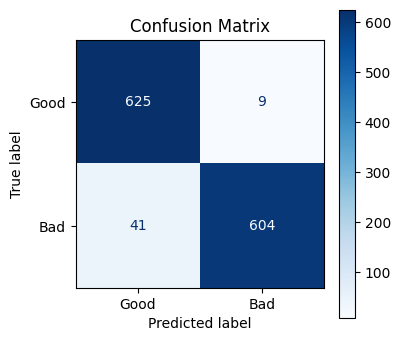

<Figure size 600x600 with 0 Axes>

In [ ]:
all_preds = []
all_labels = []
total_correct = 0
total_samples = 0

test_examples = datasets.ImageFolder(root=f'{data_root}/test', transform=transform)   # load the dataset
test_loader = DataLoader(test_examples, batch_size=4, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
model.to(device)
model.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)   # evaluate on the dataset
        predicted = torch.argmax(outputs, dim=1)
        predicted = 1 - predicted   # I made a mistake and the models were trained with the class of 1 as "good" and the class of 0 as "bad" so "1 -" reveses this effect

        total_samples += labels.size(0)
        total_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = (total_correct/total_samples) * 100
print(f"Accuracy: {accuracy:.2f}%")

#class_names = [str(i) for i in range(len(set(all_labels)))]
#class_names = test_examples.classes
class_names = ['Good', 'Bad']

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize = (4, 4))
disp.plot(cmap=plt.cm.Blues, ax=ax)    # Plot confusion matrix
plt.title("Confusion Matrix")
plt.figure(figsize=(6, 6))

print(classification_report(    # Print out classification report
    all_labels,
    all_preds,
    target_names=class_names
))